### Aplicación 1: Optimización bajo restricción de riesgo

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt

In [2]:
tickers = ["KVUE", "JPM", "CDNS", "PANW"]
n_portfolios = 60         
n_sim = 8000               
seed = 42
var_level = 0.95
var_min = -0.05          
scatter_risk = "std"

In [3]:
np.random.seed(seed)
end = dt.datetime.today()
start = end - dt.timedelta(days=365 * 3)
prices = yf.download(tickers, start=start, end=end)["Close"]
returns = prices.pct_change().dropna()
mu = returns.mean().values               
cov = returns.cov().values                
n_assets = len(tickers)

[*********************100%***********************]  4 of 4 completed


In [4]:
W = np.random.dirichlet(alpha=np.ones(n_assets), size=n_portfolios)

In [12]:
sim_asset_returns = np.random.multivariate_normal(mu, cov, size=n_sim) 

In [13]:
def var_95(x, level=0.95):
    return float(np.quantile(x, 1 - level))
rows = []

for i, w in enumerate(W):
    port_r = sim_asset_returns @ w         
    mean_r = float(np.mean(port_r))
    std_r = float(np.std(port_r, ddof=1))
    VaR95 = var_95(port_r, var_level)

    rows.append({
        "id": i,
        "mean": mean_r,
        "std": std_r,
        "VaR95": VaR95,
        "feasible": VaR95 >= var_min,
        "weights": w
    })

res = pd.DataFrame(rows)


In [14]:
feasible = res[res["feasible"]].copy()

if feasible.empty:
    print("No hay portafolios que cumplan VaR95 >= -5%.")
    best = res.sort_values("VaR95", ascending=False).iloc[0]
else:
    best = feasible.sort_values("mean", ascending=False).iloc[0]

best_id = int(best["id"])
best_w = best["weights"]

print("\n================= PORTAFOLIO ELEGIDO =================")
print(f"ID: {best_id}")
print(f"Rendimiento promedio (mean): {best['mean']:.6f}")
print(f"Desviación estándar (std):   {best['std']:.6f}")
print(f"VaR 95%:                    {best['VaR95']:.6f}  (restricción >= {var_min})\n")

print(pd.DataFrame({"Ticker": tickers, "Peso": best_w}).to_string(index=False))



================= PORTAFOLIO ELEGIDO =================
ID: 10
Rendimiento promedio (mean): 0.001197
Desviación estándar (std):   0.019770
VaR 95%:                    -0.030997  (restricción >= -0.05)

Ticker     Peso
  KVUE 0.040058
   JPM 0.210379
  CDNS 0.010770
  PANW 0.738793


In [15]:
best_port_r = sim_asset_returns @ best_w

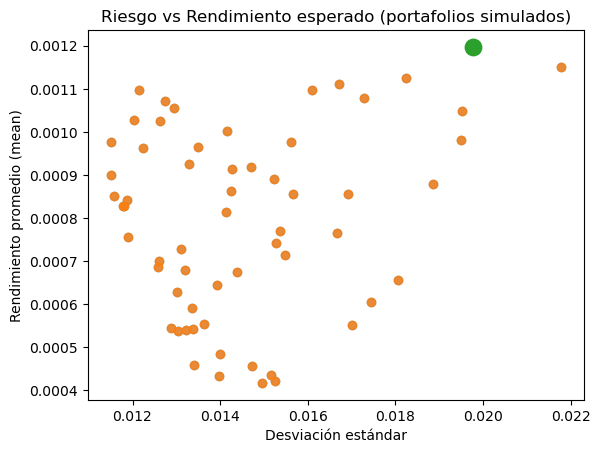

In [16]:
plt.figure()

if scatter_risk.lower() == "var":
    x = res["VaR95"].values
    xlabel = "VaR 95% (cuantil 5%)"
    plt.axvline(var_min, linestyle="--")
else:
    x = res["std"].values
    xlabel = "Desviación estándar"

plt.scatter(x, res["mean"].values, alpha=0.5)

if not feasible.empty:
    x_f = feasible["VaR95"].values if scatter_risk.lower() == "var" else feasible["std"].values
    plt.scatter(x_f, feasible["mean"].values, alpha=0.8)

x_best = best["VaR95"] if scatter_risk.lower() == "var" else best["std"]
plt.scatter([x_best], [best["mean"]], s=140)

plt.xlabel(xlabel)
plt.ylabel("Rendimiento promedio (mean)")
plt.title("Riesgo vs Rendimiento esperado (portafolios simulados)")
plt.show()

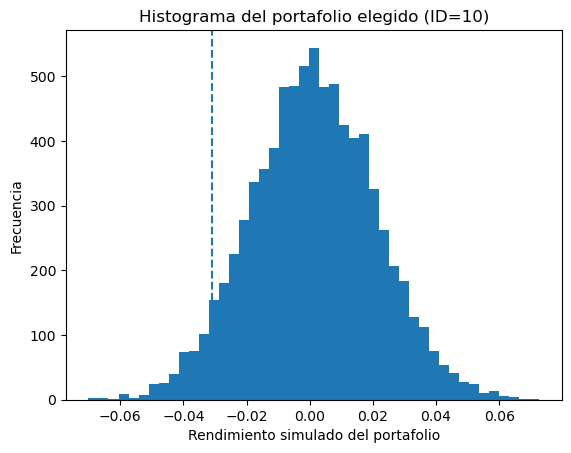

In [17]:
plt.figure()
plt.hist(best_port_r, bins=45)
plt.axvline(best["VaR95"], linestyle="--")
plt.xlabel("Rendimiento simulado del portafolio")
plt.ylabel("Frecuencia")
plt.title(f"Histograma del portafolio elegido (ID={best_id})")
plt.show()

In [18]:
print("\nTop 10 portafolios factibles por rendimiento promedio:")
print(
    res[res["feasible"]]
    .drop(columns=["weights"])
    .sort_values("mean", ascending=False)
    .head(10)
    .to_string(index=False)
)


Top 10 portafolios factibles por rendimiento promedio:
 id     mean      std     VaR95  feasible
 10 0.001197 0.019770 -0.030997      True
  1 0.001152 0.021790 -0.034794      True
  2 0.001124 0.018231 -0.028922      True
 16 0.001112 0.016709 -0.026223      True
 14 0.001098 0.016090 -0.025244      True
 41 0.001098 0.012156 -0.018998      True
 34 0.001078 0.017284 -0.027275      True
 25 0.001071 0.012740 -0.019696      True
  6 0.001056 0.012943 -0.020207      True
 47 0.001049 0.019529 -0.031185      True


**¿Cuántos portafolios cumplen la restricción?**

In [19]:
n_factibles = int(res["feasible"].sum())
n_total = len(res)

print(f"Portafolios factibles: {n_factibles} de {n_total}")
print(f"Porcentaje factible: {100*n_factibles/n_total:.2f}%")

Portafolios factibles: 60 de 60
Porcentaje factible: 100.00%


**¿Cuánto rendimiento se sacrifica por controlar riesgo?**

In [20]:
best_unconstrained = res.loc[res["mean"].idxmax()]

# Mejor CON restricción (máximo mean entre factibles)
best_constrained = res[res["feasible"]].loc[res[res["feasible"]]["mean"].idxmax()]

sacrificio_abs = float(best_unconstrained["mean"] - best_constrained["mean"])
sacrificio_pct = float(sacrificio_abs / best_unconstrained["mean"]) if best_unconstrained["mean"] != 0 else np.nan

print("\n--- Mejor SIN restricción ---")
print(f"ID: {int(best_unconstrained['id'])} | mean={best_unconstrained['mean']:.6f} | VaR95={best_unconstrained['VaR95']:.6f}")

print("\n--- Mejor CON restricción ---")
print(f"ID: {int(best_constrained['id'])} | mean={best_constrained['mean']:.6f} | VaR95={best_constrained['VaR95']:.6f}")

print("\n--- Sacrificio por restricción ---")
print(f"Sacrificio absoluto (mean): {sacrificio_abs:.6f}")
print(f"Sacrificio porcentual: {100*sacrificio_pct:.2f}%")


--- Mejor SIN restricción ---
ID: 10 | mean=0.001197 | VaR95=-0.030997

--- Mejor CON restricción ---
ID: 10 | mean=0.001197 | VaR95=-0.030997

--- Sacrificio por restricción ---
Sacrificio absoluto (mean): 0.000000
Sacrificio porcentual: 0.00%


### Aplicación 2: Escenarios macroeconómicos

In [21]:
tickers = ["KVUE", "JPM", "CDNS", "PANW"]
weights = np.array([0.040058, 0.210379, 0.010770, 0.738793])  
weights = weights / weights.sum()

lambda_ = 0.94

n_days = 252               
n_sim = 10000                
seed = 42

var_level = 0.95
mu_shift = 0.001  

In [23]:
USE_HORIZON_RETURN = True

In [24]:
rng = np.random.default_rng(seed)

end = dt.datetime.today()
start = end - dt.timedelta(days=365 * 3)

prices = yf.download(tickers, start=start, end=end)["Close"]
returns = prices.pct_change().dropna()

n_assets = len(tickers)

[*********************100%***********************]  4 of 4 completed


In [25]:
ewma_var = returns.var().copy()
ewma_vol_series = []

for t in range(len(returns)):
    r_t = returns.iloc[t]
    ewma_var = lambda_ * ewma_var + (1 - lambda_) * (r_t ** 2)
    ewma_vol_series.append(np.sqrt(ewma_var))

ewma_vol_df = pd.DataFrame(ewma_vol_series, index=returns.index, columns=returns.columns)
sigma0 = ewma_vol_df.iloc[-1].values

In [26]:
corr_matrix = returns.corr().values
L_corr = np.linalg.cholesky(corr_matrix)

In [27]:
mu_base = returns.mean().values  # (n_assets,)

In [28]:
def var_95(x, level=0.95):
    return float(np.quantile(x, 1 - level))

def simulate_horizon_portfolio(mu_vec, n_sim, n_days):
    """
    Simula n_sim trayectorias, n_days días, con:
    - correlación fija (L_corr)
    - volatilidad EWMA por trayectoria
    - shock normal correlacionado
    - media desplazada (mu_vec) aplicada como drift diario
    Retorna: vector de retornos finales (n_sim,) si USE_HORIZON_RETURN
             o vector de rendimientos diarios apilados si no.
    """
    port_daily = np.zeros((n_sim, n_days), dtype=float)

    for s in range(n_sim):
        sigma = sigma0.copy()
        for t in range(n_days):
            z = rng.normal(size=n_assets)
            correlated = L_corr @ z
            r = mu_vec + sigma * correlated
            port_daily[s, t] = float(np.dot(weights, r))
            sigma = np.sqrt(lambda_ * sigma**2 + (1 - lambda_) * (r**2))

    if USE_HORIZON_RETURN:
        wealth = np.cumprod(1.0 + port_daily, axis=1)
        horizon_ret = wealth[:, -1] - 1.0
        return horizon_ret
    else:
        return port_daily.reshape(-1)

def scenario_metrics(x):
    """
    x: retornos (horizon o diarios).
    """
    m = float(np.mean(x))
    s = float(np.std(x, ddof=1))
    p_loss = float(np.mean(x < 0))
    v95 = var_95(x, var_level)
    return m, s, p_loss, v95

In [29]:
scenarios = {
    "Base": mu_base,
    "Alcista": mu_base + mu_shift,
    "Bajista": mu_base - mu_shift,
}

In [30]:
results = []
dist = {}

for name, mu_vec in scenarios.items():
    x = simulate_horizon_portfolio(mu_vec, n_sim=n_sim, n_days=n_days)
    dist[name] = x

    m, s, p_loss, v95 = scenario_metrics(x)
    results.append({
        "Escenario": name,
        "Rendimiento_promedio": m,
        "Desviacion_estandar": s,
        "Probabilidad_perdida": p_loss,
        "VaR95": v95
    })

summary = pd.DataFrame(results).set_index("Escenario")
print("\n================= MÉTRICAS POR ESCENARIO =================")
print(summary)


================= MÉTRICAS POR ESCENARIO =================
           Rendimiento_promedio  Desviacion_estandar  Probabilidad_perdida  \
Escenario                                                                    
Base                   0.296740             0.480420                0.2522   
Alcista                0.666681             0.693732                0.0900   
Bajista                0.012691             0.398156                0.5520   

              VaR95  
Escenario            
Base      -0.313865  
Alcista   -0.131390  
Bajista   -0.464375  


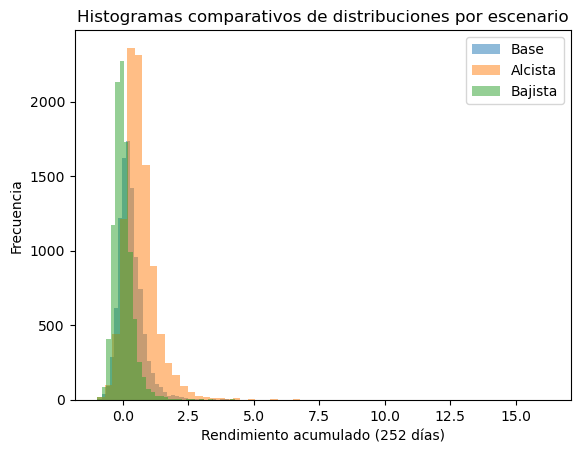

In [31]:
plt.figure()
plt.hist(dist["Base"], bins=60, alpha=0.5, label="Base")
plt.hist(dist["Alcista"], bins=60, alpha=0.5, label="Alcista")
plt.hist(dist["Bajista"], bins=60, alpha=0.5, label="Bajista")

xlabel = "Rendimiento acumulado (252 días)" if USE_HORIZON_RETURN else "Rendimiento diario"
plt.xlabel(xlabel)
plt.ylabel("Frecuencia")
plt.title("Histogramas comparativos de distribuciones por escenario")
plt.legend()
plt.show()

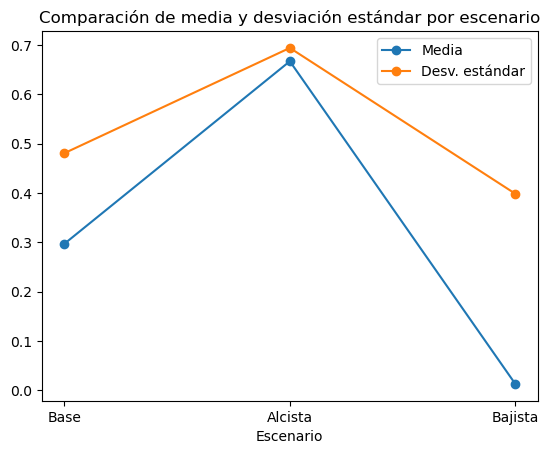

In [32]:
plt.figure()
x_names = summary.index.tolist()
means = summary["Rendimiento_promedio"].values
stds = summary["Desviacion_estandar"].values

plt.plot(x_names, means, marker="o", label="Media")
plt.plot(x_names, stds, marker="o", label="Desv. estándar")

plt.xlabel("Escenario")
plt.title("Comparación de media y desviación estándar por escenario")
plt.legend()
plt.show()

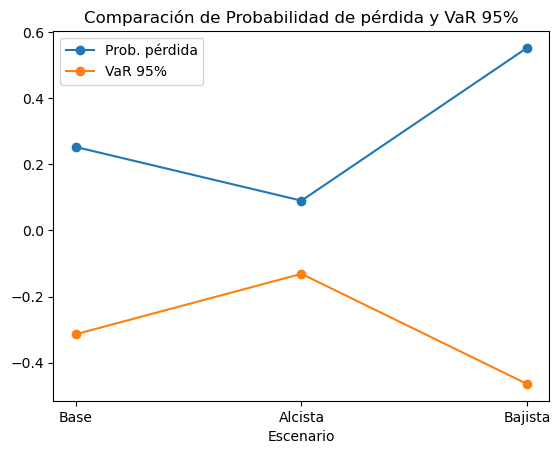

In [33]:
plt.figure()
plt.plot(x_names, summary["Probabilidad_perdida"].values, marker="o", label="Prob. pérdida")
plt.plot(x_names, summary["VaR95"].values, marker="o", label="VaR 95%")

plt.xlabel("Escenario")
plt.title("Comparación de Probabilidad de pérdida y VaR 95%")
plt.legend()
plt.show()

¿En qué escenario la probabilidad de pérdida es mayor?

En el escenario bajista se observa la mayor probabilidad de pérdida, con un 55.20% de las trayectorias terminando en rendimientos negativos. Esto indica que más de la mitad de los resultados simulados implican pérdidas bajo una reducción en la media de los rendimientos, lo cual desplaza la distribución hacia valores más bajos. En comparación, el escenario base presenta una probabilidad de pérdida de 25.22%, mientras que el escenario alcista reduce considerablemente este riesgo a solo 9.00%, reflejando el impacto positivo de aumentar la media esperada.

¿Cuál presenta mayor dispersión de resultados?

El escenario que presenta mayor dispersión de resultados es el alcista, con una desviación estándar de 0.6937. Aunque este escenario muestra el mayor rendimiento promedio, también implica una mayor variabilidad en los resultados posibles, lo que significa que los valores simulados se encuentran más dispersos alrededor de la media. En segundo lugar se encuentra el escenario base (0.4804), mientras que el escenario bajista presenta la menor desviación estándar (0.3982), lo que sugiere menor amplitud en los resultados, aunque concentrados en niveles más bajos de rendimiento.

¿Cambian de manera relevante las métricas de riesgo extremo?

Las métricas de riesgo extremo sí cambian de manera relevante entre escenarios, como lo demuestra el VaR al 95%. En el escenario alcista, el VaR es -13.14%, en el escenario base es -31.39%, y en el escenario bajista alcanza -46.44%. Esta diferencia muestra que pequeñas variaciones en la media diaria generan impactos significativos en el riesgo acumulado anual. El escenario bajista incrementa considerablemente el riesgo extremo, mientras que el escenario alcista lo reduce de forma notable, evidenciando la sensibilidad del portafolio ante cambios en el entorno esperado de rendimientos.